# Boston City: Merge and Clean Data for Massachusetts Crash Map 
# (Expected Runtime: 5-8 minutes)
## Jack removed Cambridge, Somerville, Brookline due to Cambridge geocoding issue

Output: 3 files in /data folder:
* boston-core-all-merged.csv - contains ALL MERGED crash records from different sources, including duplicates
* boston-core-duplicates-removed.csv - contains DUPLICATES REMOVED and displayed as side-by-side pairs of matched crash records for easy comparison
* boston-core.csv - contains CLEANED data, after duplicates removed, with one instance for each crash, prioritizing MassDOT data because it is more comprehensive

If unable to run this notebook, earlier datasets can be found in this google drive folder named Mass_Crash_Map_Data:
https://drive.google.com/drive/folders/14pxdYQC73GC8VB6watQnqMJ_IBIHDGVv?usp=drive_link

# Importing all libraries

In [1]:
# !pip install googlemaps
# uncomment the line above if we decide to pay for GOOGLE CLOUD, an estimate of the cost is below $200
# GOOGLE CLOUD can be used to geocode 16911 crashes that have addresses but not lon and lat
# more information on how to do this can be found here: https://tinyurl.com/mr42hkxw
!pip install pandas
!pip install numpy
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


# Collecting MassDOT crashes for Boston city ONLY (update in 2027)

In [2]:
all_features = []

years = ['2022','2023v','2024','2025','2026']

for year in years:
   
    base_url = f"https://gis.crashdata.dot.mass.gov/arcgis/rest/services/MassDOT/MASSDOT_ODP_OPEN_{year}/FeatureServer/0/query"
    
    params = {
        "where": " CITY_TOWN_NAME = 'BOSTON' ",
        "outFields": "*",
        "outSR": "4326",
        "f": "json",
        "returnGeometry": "true",
        "resultOffset": 0,
        "resultRecordCount": 2000
    }

    while True:
        
        response = requests.get(base_url, params=params)
        data = response.json()
        features = data.get("features", [])
        
        if not features:
            break
        
        all_features.extend(features)
        params["resultOffset"] += params["resultRecordCount"]

records = [f["attributes"] for f in all_features]

df = pd.DataFrame(records)
print("Shape:", df.shape)
df.head()

Shape: (25252, 124)


,CRASH_NUMB,CITY_TOWN_NAME,CRASH_DATE_TEXT,CRASH_TIME_2,CRASH_DATETIME,CRASH_HOUR,CRASH_STATUS,CRASH_SEVERITY_DESCR,MAX_INJR_SVRTY_CL,NUMB_VEHC,...,T_EXC_TIME,F_F_CLASS,OBJECTID,TRAFFIC_CONTROL_TYPE_DESCR,NON_MTRST_ORIGIN_DEST_CL,NON_MTRST_CNTRB_CIRC_CL,NON_MTRST_DISTRACTED_BY_CL,NON_MTRST_ALC_SUSPD_TYPE_CL,NON_MTRST_DRUG_SUSPD_TYPE_CL,NON_MTRST_EVENT_SEQ_CL
0,5054461,BOSTON,01 02 2022,1:39 AM,1641105540000,01:00AM to 01:59AM,Closed,Property damage only (none injured),No Apparent Injury (O),2,...,NaN,Principal Arterial - Other,4744161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5054385,BOSTON,01 01 2022,8:09 PM,1641085740000,08:00PM to 08:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,...,NaN,Interstate,4744237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5054357,BOSTON,01 03 2022,6:29 PM,1641252540000,06:00PM to 06:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,...,NaN,Principal Arterial - Other,4744265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5054222,BOSTON,01 01 2022,8:45 AM,1641044700000,08:00AM to 08:59AM,Closed,Property damage only (none injured),No Apparent Injury (O),1,...,NaN,Principal Arterial - Other Freeways or Express...,4744400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5054212,BOSTON,01 01 2022,6:12 PM,1641078720000,06:00PM to 06:59PM,Closed,Non-fatal injury,Suspected Minor Injury (B),1,...,NaN,Interstate,4744410,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
#CRASH_TIME_2 & CRASH_DATE_TEXT columns are of type str
#LAT & LON are of type float64
#The following code ensures time and date are of type datetime and lat and lon are numeric
df["CRASH_TIME"] = pd.to_datetime(df["CRASH_TIME_2"], format="%I:%M %p", errors="coerce").dt.time
df["CRASH_DATE"] = pd.to_datetime(df["CRASH_DATE_TEXT"], errors="coerce")
df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
df = df.drop(columns=["CRASH_DATE_TEXT", "CRASH_TIME_2"])
mass_crashes = df
print("Shape of MASSDOT dataset:", mass_crashes.shape)
mass_crashes.head()

Shape of MASSDOT dataset: (25252, 124)


,CRASH_NUMB,CITY_TOWN_NAME,CRASH_DATETIME,CRASH_HOUR,CRASH_STATUS,CRASH_SEVERITY_DESCR,MAX_INJR_SVRTY_CL,NUMB_VEHC,NUMB_NONFATAL_INJR,NUMB_FATAL_INJR,...,OBJECTID,TRAFFIC_CONTROL_TYPE_DESCR,NON_MTRST_ORIGIN_DEST_CL,NON_MTRST_CNTRB_CIRC_CL,NON_MTRST_DISTRACTED_BY_CL,NON_MTRST_ALC_SUSPD_TYPE_CL,NON_MTRST_DRUG_SUSPD_TYPE_CL,NON_MTRST_EVENT_SEQ_CL,CRASH_TIME,CRASH_DATE
0,5054461,BOSTON,1641105540000,01:00AM to 01:59AM,Closed,Property damage only (none injured),No Apparent Injury (O),2,0,0,...,4744161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01:39:00,2022-01-02
1,5054385,BOSTON,1641085740000,08:00PM to 08:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,0,0,...,4744237,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20:09:00,2022-01-01
2,5054357,BOSTON,1641252540000,06:00PM to 06:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,0,0,...,4744265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18:29:00,2022-01-03
3,5054222,BOSTON,1641044700000,08:00AM to 08:59AM,Closed,Property damage only (none injured),No Apparent Injury (O),1,0,0,...,4744400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,08:45:00,2022-01-01
4,5054212,BOSTON,1641078720000,06:00PM to 06:59PM,Closed,Non-fatal injury,Suspected Minor Injury (B),1,1,0,...,4744410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18:12:00,2022-01-01


# Collecting all Crash Data from City of Boston Vision Zero, then limit to 2022 onward

In [4]:
package_url = "https://data.boston.gov/api/3/action/package_show"
dataset_id = "vision-zero-crash-records"

package = requests.get(package_url, params={"id": dataset_id}).json()["result"]

resource_id = None

for r in package["resources"]:
    
    if r.get("datastore_active"):
        resource_id = r["id"]
        break

if not resource_id:
    raise Exception("No datastore-enabled resource found.")

datastore_url = "https://data.boston.gov/api/3/action/datastore_search"

limit = 5000
offset = 0
all_records = []

while True:
    
    params = {
        "resource_id": resource_id,
        "limit": limit,
        "offset": offset
    }

    response = requests.get(datastore_url, params=params).json()
    records = response["result"]["records"]

    all_records.extend(records)

    if len(records) < limit:
        break

    offset += limit

df = pd.DataFrame(all_records)
print("Shape:",df.shape)
df.head()

Shape: (42681, 11)


,_id,dispatch_ts,mode_type,location_type,street,xstreet1,xstreet2,x_cord,y_cord,lat,long
0,1,2017-12-06 10:42:22+00,mv,Street,I93 NULL,NULL,NULL,775067.210000000000,2958589.910000000000,42.36567289376716,-71.06004594188641
1,2,2018-12-10 22:05:11+00,mv,Intersection,NaN,ELLARD RD,WOOD AVE,761691.900000000000,2921868.340000000000,42.265093251264574,-71.1101448684369
2,3,2020-08-01 07:04:13+00,mv,Street,FULLER ST,CAPEN ST,MORTON ST,769525.770000000000,2927350.960000000000,42.279875098295534,-71.08103972895782
3,4,2022-07-28 10:41:15+00,mv,Intersection,NaN,WEST ST,RIVER ST,759580.580000000000,2919545.840000000000,42.258746336095875,-71.11798330639114
4,5,2024-10-17 03:43:17+00,mv,Intersection,NaN,WOODFIELD ST,GALLIVAN BLVD,777459.330000000000,2928572.020000000000,42.28327605450428,-71.05176412546767


In [5]:
# the dispatch_ts columns is of type str and contains information about the date and time
# lat and lon are also of type str
# the following code ensures time and date are of type datetime and lon and lat are numeric
df["CRASH_DATE"] = pd.to_datetime(df["dispatch_ts"]).dt.date
df["CRASH_TIME"] = pd.to_datetime(df["dispatch_ts"]).dt.time
df['LAT'] = df['lat']
df['LON'] = df['long']
df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
df['CITY_TOWN_NAME'] = 'BOSTON'
df = df[pd.to_datetime(df["dispatch_ts"]).dt.year >=2022]
df = df.drop(columns=["lat", "long","dispatch_ts"])
bvz_crashes = df
print("Shape of Boston Vision Zero dataset:",bvz_crashes.shape)
bvz_crashes.head()

Shape of Boston Vision Zero dataset: (13704, 13)


,_id,mode_type,location_type,street,xstreet1,xstreet2,x_cord,y_cord,CRASH_DATE,CRASH_TIME,LAT,LON,CITY_TOWN_NAME
3,4,mv,Intersection,NaN,WEST ST,RIVER ST,759580.580000000000,2919545.840000000000,2022-07-28,10:41:15,42.258746,-71.117983,BOSTON
4,5,mv,Intersection,NaN,WOODFIELD ST,GALLIVAN BLVD,777459.330000000000,2928572.020000000000,2024-10-17,03:43:17,42.283276,-71.051764,BOSTON
7,8,mv,Street,I93,NaN,NaN,777311.540000000000,2954652.680000000000,2022-01-14,21:50:58,42.354835,-71.051794,BOSTON
8,9,bike,Street,PERRIN ST,MORELAND ST,MURRAY AVE,770171.490000000000,2942896.860000000000,2025-09-30,18:49:28,42.322549,-71.078236,BOSTON
14,15,mv,Street,BERKELEY ST,ALBANY ST,HARRISON AVE,774276.510000000000,2950247.200000000000,2025-07-31,14:11:37,42.343110,-71.062971,BOSTON


# SKIP Collecting all Crash Data from Cambridge PD, then limit to 2022 onward

In [6]:
# APP_TOKEN = "LfkihW5e09LSy1YiqpcxGzhpc" 

# base_url = "https://data.cambridgema.gov/resource/h6fp-bp8s.json"

# all_rows = []
# limit = 5000  
# offset = 0

# while True:
    
#     params = {
#         "$limit": limit,
#         "$offset": offset
#     }
    
#     if APP_TOKEN:
#         headers = {"X-App-Token": APP_TOKEN}
#         response = requests.get(base_url, params=params, headers=headers)
#     else:
#         response = requests.get(base_url, params=params)
    
#     data = response.json()
    
#     if not data:  
#         break
    
#     all_rows.extend(data)
#     offset += limit

# df = pd.DataFrame(all_rows)
# print("Shape:", df.shape)
# df.head()

In [7]:
# the datetime column is of str type
# the following code ensures that the date and time are of datetime type
#
# df["CRASH_TIME"] = pd.to_datetime(df["datetime"]).dt.time
# df["CRASH_DATE"] = pd.to_datetime(df["datetime"]).dt.date
# df["CITY_TOWN_NAME"] = 'CAMBRIDGE'
# df = df[pd.to_datetime(df["datetime"]).dt.year >=2022]
# df = df.drop(columns=["datetime"])
# ca_crashes = df
# print("Shape:", ca_crashes.shape)
# ca_crashes.head()

# SKIP Collecting all data from Somerville PD, then limit to 2022 onward

In [8]:
# APP_TOKEN = "LfkihW5e09LSy1YiqpcxGzhpc" 

# url = "https://data.somervillema.gov/api/v3/views/mtik-28va/query.json"

# headers = {
#     "Content-Type": "application/json",
#     "X-App-Token": APP_TOKEN
# }

# payload = {
#     "query": "SELECT *",
#     "page": {
#         "pageNumber": 1,
#         "pageSize": 5000
#     }
# }

# response = requests.post(url, json=payload, headers=headers)
# rows = response.json()   

# df = pd.DataFrame(rows)
# print(df.shape)
# df.head()

In [9]:
# the dtcrash columns has the date and time of each crash and is of type str
# the lon and lat columns are of type str
# the following code ensures lon and lat are numeric and that the date and time are of type datetime
#
# df["CRASH_TIME"] = pd.to_datetime(df["dtcrash"], format="mixed", errors="coerce").dt.time
# df["CRASH_DATE"] = pd.to_datetime(df["dtcrash"],format="mixed", errors="coerce").dt.date
# df['CRASH_NUMB'] = df["crashnum"]
# df['LAT'] = df['latitude']
# df['LON'] = df['longitude']
# df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
# df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
# df['CITY_TOWN_NAME'] = 'SOMERVILLE'
# df = df[pd.to_datetime(df["dtcrash"],format="mixed", errors="coerce").dt.year >=2022]
# df = df.drop(columns=["latitude", "longitude", "crashnum", "dtcrash"])
# so_crashes = df
# print("Shape:", so_crashes.shape)
# so_crashes.head()

# Standardizing Different Types of Vulernable Roadway Users

See README for more detailed methodology about MassDOT data

The following code creates new columns with numerical values:
* PEDESTRIAN column = 1 if a pedestrian or similar low-speed user was involved in a crash, otherwise = 0
* CYCLIST column = 1 if a cyclist or similar micromobility user was involved in a crash, otherwise = 0
* OTHER column = 1 if higher-speed user or other type listed above or unknown was involved in a crash, otherwise = 0


In [10]:
col1 = mass_crashes["NON_MTRST_TYPE_CL"]
col2 = mass_crashes["MOST_HRMFL_EVT_CL"]

mass_crashes["PEDESTRIAN"] = np.where(
    col1.str.contains("Pedestrian|Electric Personal Assistive Mobility Device|Wheelchair|Responder|Worker", case=False, na=False) |
    col2.str.contains("Pedestrian", case=False, na=False),
    1,
    0
)

#contains Bicyclist = 1, but if "Motorized" = false
mass_crashes["CYCLIST"] = np.where(
    (
        col1.str.contains("Bicyclist|Cyclist|Skater|Non-Motorized Scooter Rider|Micromobility|Skateboarder|Tricyclist", case=False, na=False) |
        col2.str.contains("Cyclist", case=False, na=False)
    )
    &
    ~(
        col1.str.contains("Motorized", case=False, na=False) |
        col2.str.contains("Motorized", case=False, na=False)
    ),
    1,
    0
)

mass_crashes["OTHER"] = np.where(
    mass_crashes["NON_MTRST_TYPE_CL"].str.contains("Other|Motorized|Passenger|Farm|Unknown", case=False, na=False) |
    mass_crashes["MOST_HRMFL_EVT_CL"].str.contains("Other Vulnerable|moped", case=False, na=False),
    1,
    0
)

mass_crashes['SEVERITY'] = mass_crashes['CRASH_SEVERITY_DESCR'].map({
    'Fatal injury': 1,
    'Non-fatal injury': 2
}).fillna(0)


mass_crashes['INTERSTATE'] = np.where(
    mass_crashes['F_CLASS'].str.contains("Interstate", case=False, na=False),
    1,
    0
)

#trims "Local police" to "Local", "State police" to "State", etc
mass_crashes['POLICE'] = mass_crashes['POLC_AGNCY_TYPE_DESCR'].str.split().str[0]
mass_crashes['ID'] = mass_crashes['CRASH_NUMB']
mass_crashes['MUNI'] = mass_crashes['CITY_TOWN_NAME']
mass_crashes = mass_crashes.drop(columns=["CITY_TOWN_NAME", "CRASH_NUMB", "POLC_AGNCY_TYPE_DESCR"])
mass_crashes['SOURCE'] = 'MassDOT'
mass_crashes['YEAR'] = pd.to_datetime(mass_crashes["CRASH_DATE"]).dt.year

**Standardizing Boston Vision Zero crashes**

In [11]:
bvz_crashes['CYCLIST'] = np.where(
    bvz_crashes['mode_type'] == 'bike',
    1,
    0)

bvz_crashes['PEDESTRIAN'] = np.where(
    bvz_crashes['mode_type'] == 'ped',
    1,
    0)

bvz_crashes['OTHER'] = np.where(
    bvz_crashes['mode_type'] == 'mv',
    1,
    0)

bvz_crashes['POLICE'] = ''
bvz_crashes['INTERSTATE'] = ''
bvz_crashes['SEVERITY'] = ''
bvz_crashes['ID'] = bvz_crashes['_id']
bvz_crashes['MUNI'] = bvz_crashes['CITY_TOWN_NAME']
bvz_crashes = bvz_crashes.drop(columns=["_id", "CITY_TOWN_NAME"])
bvz_crashes['SOURCE'] = 'BostonVisionZero'
bvz_crashes['YEAR'] = pd.to_datetime(bvz_crashes["CRASH_DATE"]).dt.year

**SKIP Standardizing Cambridge PD crashes**

Cambridge does not differentiate between fatal and non-fatal injuries.

Therefore, all injuries were classified as a 2, meaning non-fatal as explained below.

In [12]:
# conditions = [
#     ca_crashes['injuries'].astype(float) >= 1.0
# ]

# choices = [2]

# ca_crashes['SEVERITY'] = np.select(conditions, choices, default=0)

# ca_crashes['CYCLIST'] = np.where(
#     ca_crashes['cyclists'].astype(float) >= 1.0,
#     1,
#     0)

# ca_crashes['PEDESTRIAN'] = np.where(
#     ca_crashes['pedestrians'].astype(float) >= 1.0,
#     1,
#     0)

# ca_crashes['OTHER'] = np.where(
#     ca_crashes['motorists'].astype(float) >= 1.0,
#     1,
#     0)

# ca_crashes['POLICE'] = ''
# ca_crashes['INTERSTATE'] = ''
# ca_crashes['ID'] = 'CPD_' + ca_crashes.index.astype(str)
# ca_crashes['MUNI'] = ca_crashes['CITY_TOWN_NAME']
# ca_crashes = ca_crashes.drop(columns=["CITY_TOWN_NAME"])
# ca_crashes['SOURCE'] = 'CambridgePD'
# ca_crashes['YEAR'] = pd.to_datetime(ca_crashes["CRASH_DATE"]).dt.year

**SKIP Standardizing Somerville PD crashes**

In [13]:
# conditions = [
#     so_crashes['fatalinjury'].astype('float') == 1.0,
#     (
#         (so_crashes['suspectedseriousinjury'].astype(float) >= 1.0) |
#         (so_crashes['suspectedminorinjury'].astype(float) >= 1.0) |
#         (so_crashes['possibleinjury'].astype(float) >= 1.0)
#     )
# ]
# choices = [1, 2]

# so_crashes['SEVERITY'] = np.select(conditions, choices, default=0)

# so_crashes['CYCLIST'] = np.where(
#     so_crashes['nonmotoristcyclist'].astype(float) >= 1.0,
#     1,
#     0)

# so_crashes['PEDESTRIAN'] = np.where(
#     so_crashes['nonmotoristpedestrian'].astype(float) >= 1.0,
#     1,
#     0)

# so_crashes['OTHER'] = np.where(
#     so_crashes['nonmotoristother'].astype(float) >= 1.0,
#     1,
#     0)

# so_crashes['POLICE'] = ''
# so_crashes['INTERSTATE'] = ''
# so_crashes['ID'] = so_crashes['CRASH_NUMB']
# so_crashes['MUNI'] = so_crashes['CITY_TOWN_NAME']
# so_crashes = so_crashes.drop(columns=["CRASH_NUMB", "CITY_TOWN_NAME"])
# so_crashes['SOURCE'] = 'SomervillePD'
# so_crashes['YEAR'] = pd.to_datetime(so_crashes["CRASH_DATE"]).dt.year

# Merging all Crash data

**All datasets are merged into one dataset that has the following structure:**

**Columns are attributes of each individual crash:**

* SOURCE: specifies where the crash data comes from(MASSDOT, Vision Zero, Somerville
PD and Cambridge PD)
* ID: unique identifier of each crash. Cambridge PD did not have an ID attribute so one
was created by adding CPD_ to the index number of each crash.
* MUNI: specifies the area each crash occurred(Boston, Cambridge, Brookline,
Somerville)
* YEAR: in YYYY format (for easier data quality checks)
* DATE: the date each crash occurred in this format YEAR-MONTH-DAY
* SEVERITY: it is 1 if the crash was fatal, 2 if the crash resulted in nonfatal injuries and
blank if neither
* CRASH_TIME: time each crash occured
* POLICE: specifies if Local, State, MBTA or Campus police reported the crash
* CYCLIST: 1 if cyclist was involved in the crash, 0 if not
* PEDESTRIAN: 1 if pedestrian was involved in the crash, 0 if not
* OTHER: 1 if other vulnerable user was involved in the crash, 0 if not
* LAT: latitude of the location where the crash occurred
* LON: longitude of the location where the crash occurred
* INTERSTATE: 1 if the crash occurred on an interstate highway, 0 if not (only in MassDOT data)

In [14]:
combined = pd.concat([
    mass_crashes,
    bvz_crashes
    # REMOVED COMMA after bvz_crashes
    # so_crashes,
    # ca_crashes
], ignore_index=True)

In [15]:
cols_to_move = [
    "SOURCE",
    
    "ID",

    "MUNI",

    "YEAR",

    "CRASH_DATE",

    "SEVERITY",

    "CRASH_TIME",

    "POLICE",

    "CYCLIST",

    "PEDESTRIAN",

    "OTHER",

    "LAT",

    "LON",

    "INTERSTATE"
    
]
df = combined[cols_to_move + [c for c in combined.columns if c not in cols_to_move]]
df.head()

,SOURCE,ID,MUNI,YEAR,CRASH_DATE,SEVERITY,CRASH_TIME,POLICE,CYCLIST,PEDESTRIAN,...,NON_MTRST_ALC_SUSPD_TYPE_CL,NON_MTRST_DRUG_SUSPD_TYPE_CL,NON_MTRST_EVENT_SEQ_CL,mode_type,location_type,street,xstreet1,xstreet2,x_cord,y_cord
0,MassDOT,5054461,BOSTON,2022,2022-01-02 00:00:00,0.0,01:39:00,State,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MassDOT,5054385,BOSTON,2022,2022-01-01 00:00:00,0.0,20:09:00,State,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MassDOT,5054357,BOSTON,2022,2022-01-03 00:00:00,0.0,18:29:00,State,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MassDOT,5054222,BOSTON,2022,2022-01-01 00:00:00,0.0,08:45:00,State,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MassDOT,5054212,BOSTON,2022,2022-01-01 00:00:00,2.0,18:12:00,State,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# UPDATE INDEX AS NEEDED: We keep only relevant columns and drop rows that don't have a date
df_short = df.iloc[:, :14]
df_short = df_short.dropna(subset=["CRASH_DATE"])

In [17]:
# We make sure numerical data is of type int or float, and strings of type str
df_short["CRASH_DATE"] = pd.to_datetime(df_short["CRASH_DATE"]).dt.date
df_short['SEVERITY'] = pd.to_numeric(df_short['SEVERITY'], errors='coerce').astype('Int64')
df_short['INTERSTATE'] = df_short['INTERSTATE'].astype(str)
df_short['ID'] = df_short['ID'].astype(str)

In [18]:
df_short.info()

<class 'pandas.DataFrame'>
RangeIndex: 38956 entries, 0 to 38955
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SOURCE      38956 non-null  str    
 1   ID          38956 non-null  str    
 2   MUNI        38956 non-null  str    
 3   YEAR        38956 non-null  int32  
 4   CRASH_DATE  38956 non-null  object 
 5   SEVERITY    25252 non-null  Int64  
 6   CRASH_TIME  38956 non-null  object 
 7   POLICE      38954 non-null  object 
 8   CYCLIST     38956 non-null  int64  
 9   PEDESTRIAN  38956 non-null  int64  
 10  OTHER       38956 non-null  int64  
 11  LAT         36572 non-null  float64
 12  LON         36572 non-null  float64
 13  INTERSTATE  38956 non-null  str    
dtypes: Int64(1), float64(2), int32(1), int64(3), object(3), str(4)
memory usage: 4.0+ MB


# Finding Duplicates Under Different conditions

In [19]:
# We combine crash date and crash time into one proper datetime column
# This allows us to compare crashes in time correctly

df = df_short.copy()

df["datetime"] = pd.to_datetime(
    df["CRASH_DATE"].astype(str) + " " + df["CRASH_TIME"].astype(str),
    errors="coerce"
)

# Sort data by time so earlier crashes come before later ones
df = df.sort_values("datetime").reset_index(drop=True)

In [20]:
# This function calculates the approximate Euclidean distance in meters 
# between two geographic coordinates (latitude and longitude)

def distance_meters(lat1, lon1, lat2, lon2):
    return np.sqrt(
        ((lat1 - lat2) * 111_000)**2 +
        ((lon1 - lon2) * 111_000 * np.cos(np.radians(lat1)))**2
    )


In [21]:
# This gives a score between 0 and 1 that tells us:
# "How likely are these two crashes actually the same event?"
# - 1.0 = almost certainly the same crash
# - 0.0 = very unlikely to be the same crash
# It uses:
# - distance (closer = more likely)
# - time difference (closer in time = more likely)

def compute_confidence(dist, dt, eps_meters, eps_seconds):

    # Convert distance into a score (closer = higher score)
    spatial = 1 - (dist / eps_meters)

    # Convert time difference into a score (closer in time = higher score)
    time = 1 - (dt / eps_seconds)

    # Make sure scores stay between 0 and 1
    spatial = max(0, min(1, spatial))
    time = max(0, min(1, time))

    # Combine both scores 
    # space is prioritized since time is not reliable as discussed
    return 0.7 * spatial + 0.3 * time


In [22]:
# This function compares crashes and finds pairs that might be duplicates
# Instead of comparing every possible pair,
# we only compare crashes that happen within a specific time window.

def find_duplicates(df, eps_meters, eps_minutes):

    EPS_SECONDS = eps_minutes * 60  # convert minutes to seconds

    duplicate_pairs = []  # this stores matching crash pairs

    n = len(df)

    # Go through each crash one by one
    for i in range(n):
        row_i = df.iloc[i]

        # Look at all future crashes after this one
        for j in range(i + 1, n):
            row_j = df.iloc[j]

            # How far apart in time are the two crashes?
            dt = (row_j["datetime"] - row_i["datetime"]).total_seconds()

            # If too far apart in time, stop checking further
            # (because data is sorted, everything after will be even farther)
            if dt > EPS_SECONDS:
                break

            # We only compare crashes from different data sources
            # (same source duplicates are ignored, but can change if this is a problem too)
            if row_i["SOURCE"] == row_j["SOURCE"]:
                continue

            # Skip rows with missing location data
            if pd.isna(row_i["LAT"]) or pd.isna(row_j["LAT"]):
                continue

            # Compute how far apart they are in space in meters
            dist = distance_meters(
                row_i["LAT"], row_i["LON"],
                row_j["LAT"], row_j["LON"]
            )

            # If they are close enough in space, we consider them a possible duplicate
            if dist <= eps_meters:

                # Compute confidence score: How certain are we this is a duplicate?
                conf = compute_confidence(dist, dt, eps_meters, EPS_SECONDS)

                # Store the pair and all useful information
                duplicate_pairs.append((i, j, dist, dt, conf))

    return duplicate_pairs

In [23]:
# We try many different threshholds to see how sensitive the results are

# time is in minutes
time_thresholds = [2, 10, 30, 60]

# distance is in meters
# to change the units, the distance_meters function needs to change
distance_thresholds = [5, 30, 50, 100]

results = []

# Try every combination of time & distance thresholds
for t in time_thresholds:
    for d in distance_thresholds:

        pairs = find_duplicates(df, d, t)

        # average confidence helps us understand match quality
        avg_conf = np.mean([p[4] for p in pairs]) if len(pairs) > 0 else 0

        results.append({
            "minutes": t,
            "meters": d,
            "num_pairs": len(pairs),
            "avg_confidence": avg_conf
        })

df_results = pd.DataFrame(results)

print("\nTHRESHOLD TEST RESULTS")
print(df_results.sort_values("num_pairs"))


THRESHOLD TEST RESULTS
    minutes  meters  num_pairs  avg_confidence
0         2       5        188        0.527356
1         2      30        346        0.653535
2         2      50        393        0.679432
3         2     100        461        0.704390
4        10       5        523        0.584446
8        30       5        718        0.620997
12       60       5        780        0.642022
5        10      30       1052        0.689140
6        10      50       1206        0.710268
7        10     100       1406        0.738826
9        30      30       1443        0.730954
13       60      30       1552        0.755183
10       30      50       1650        0.753892
14       60      50       1776        0.777838
11       30     100       1962        0.773926
15       60     100       2108        0.799235


In [24]:
# These are the thresholds we decide to use after reviewing results
EPS_MINUTES = 60
EPS_METERS = 100

duplicate_pairs = find_duplicates(df, EPS_METERS, EPS_MINUTES)

In [25]:
# This creates a dataset where each row contains:
# - crash A
# - crash B
# - distance between them
# - time difference
# - confidence score

pairs = []

for i, j, dist, dt, conf in duplicate_pairs:

    row_i = df.iloc[i].add_prefix("A_")
    row_j = df.iloc[j].add_prefix("B_")

    combined = pd.concat([row_i, row_j])

    combined["distance_m"] = dist
    combined["time_diff_sec"] = dt
    combined["confidence"] = conf

    pairs.append(combined)

df_pairs = pd.DataFrame(pairs).reset_index(drop=True)

In [26]:
# Creating a clean dataset without duplicates
# We decide which rows to remove so each crash appears only once
to_drop = set()

for i, j, _, _, _ in duplicate_pairs:

    # Prefer keeping MassDOT records when duplicates exist
    if df.loc[j, "SOURCE"] == "MassDOT":
        to_drop.add(i)
    elif df.loc[i, "SOURCE"] == "MassDOT":
        to_drop.add(j)
    else:
        # otherwise just drop one of them
        to_drop.add(j)

df_clean = df.drop(index=to_drop).reset_index(drop=True)


# This is the original dataset with duplicates
df_all = df_short.copy()

In [27]:
# Summary of results
print("\nFINAL SUMMARY")
print(f"Time threshold     : {EPS_MINUTES} minutes")
print(f"Distance threshold : {EPS_METERS} meters")
print(f"Number of duplicate pairs found : {len(df_pairs)}")
print(f"Average confidence score         : {df_pairs['confidence'].mean() if len(df_pairs) else 0:.3f}")

print("\nDATASET SIZES")
print(f"Original dataset : {len(df_all):,}")
print(f"Clean dataset    : {len(df_clean):,}")
print(f"Duplicate pairs  : {len(df_pairs):,}")


FINAL SUMMARY
Time threshold     : 60 minutes
Distance threshold : 100 meters
Number of duplicate pairs found : 2108
Average confidence score         : 0.799

DATASET SIZES
Original dataset : 38,956
Clean dataset    : 36,852
Duplicate pairs  : 2,108


### Renaming columns to align with Mass Crash Map¶

In [28]:
renaming = {
    "LAT": "lat",
    "LON": "lng",
    "YEAR": "year",
    "CRASH_DATE": "date",
    "CRASH_TIME": "time",
    "CYCLIST": "cyclist",
    "PEDESTRIAN": "pedestrian",
    "OTHER": "other",
    "INTERSTATE": "interstate",
    "SEVERITY": "severity",
    "ID": "id",
    "MUNI": "muni",
    "SOURCE": "source",
    "POLICE": "police"
}

df_all = df_all.rename(columns= renaming)
df_clean = df_clean.rename(columns= renaming)
df_pairs = df_pairs.rename(columns= renaming)

In [29]:
df_all.to_csv("data/boston-city-all-merged.csv")
df_pairs.to_csv("data/boston-city-duplicates-removed.csv")
df_clean.to_csv("data/boston-city.csv")


### How many bike crashes from local source (Boston Vision Zero) are not reported in MASSDOT from 2022-2026?¶

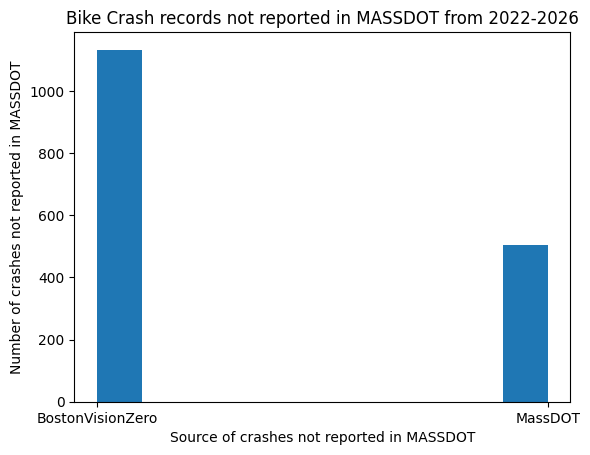

In [30]:
df_clean[(df_clean['cyclist'] == 1) & (df_clean['source'] != "MASSDOT")]['source'].hist()
plt.xlabel('Source of crashes not reported in MASSDOT')
plt.ylabel('Number of crashes not reported in MASSDOT')
plt.title('Bike Crash records not reported in MASSDOT from 2022-2026')
plt.grid(False)
plt.show()

**The following code can be used to geocode crash locations based on their address for Cambridge PD data.**

**It cannot be run at the moment as we don't have access to GOOGLE CLOUD**

### o